In [1]:

import pandas as pd
import numpy as np

df = pd.read_csv('credit_risk_dataset.csv')
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [2]:
# check  the data types and non null counts
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None


In [3]:
# Look for red flags (outliers)
print(df.describe())

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

In [4]:
print(df.isnull().any())

person_age                    False
person_income                 False
person_home_ownership         False
person_emp_length              True
loan_intent                   False
loan_grade                    False
loan_amnt                     False
loan_int_rate                  True
loan_status                   False
loan_percent_income           False
cb_person_default_on_file     False
cb_person_cred_hist_length    False
dtype: bool


In [5]:
# This tells you Exactly how many cells are empty in each column
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [6]:

# we are going to use to implement techniques
# 1. Safe Fill
# buisness logic
#Because employment length is "skewed" (most people have 2-5 years, but a few have 40). The Mean (average) would be
# pulled too high by those seniors, but the Median will give correct assumptions value
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [7]:

# we are going to use to implement techniques
# 1. Safe Fill
# buisness logic
#Because employment length is "skewed" (most people have 2-5 years, but a few have 40). The Mean (average) would be
# pulled too high by those seniors, but the Median will give correct assumptions value
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [9]:
# second technique
# Smart fill (Grouped Imputation)
# We will find the average interest rate for each Loan Grade and fill the missing value based on that person's specific grade.
df['loan_int_rate'] = df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('median'))

In [10]:
print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [11]:
# find the outliers
# check the person age is over 100 or not?
# emp_length is over 60 or not?
print(df[['person_age','person_emp_length']].describe())

         person_age  person_emp_length
count  32581.000000       32581.000000
mean      27.734600           4.767994
std        6.348078           4.087372
min       20.000000           0.000000
25%       23.000000           2.000000
50%       26.000000           4.000000
75%       30.000000           7.000000
max      144.000000         123.000000


In [12]:
# Cleaning Outliers
# Filtering age <= 100 and employment length <= 60 years
df = df[(df['person_age'] <= 100) & (df['person_emp_length'] <= 60)]
# double-check
print(df[['person_age','person_emp_length']].describe())


         person_age  person_emp_length
count  32574.000000       32574.000000
mean      27.718426           4.760576
std        6.204987           3.981181
min       20.000000           0.000000
25%       23.000000           2.000000
50%       26.000000           4.000000
75%       30.000000           7.000000
max       94.000000          41.000000


In [13]:
print(df.shape)

(32574, 12)


In [ ]:
# now we are starting eda from here
# Target Variable

In [14]:
# there is need to see how many people defaulted vs stayed safe
# health check
print(df['loan_status'].value_counts(normalize=True)*100)

loan_status
0    78.181986
1    21.818014
Name: proportion, dtype: float64


<!-- Now fter reading this above count we have this proportion people default vs safed people -->

## this is baseline risk of the bank

In [ ]:
# Step-2 : The "Risk Map" (Correlation)
# we want to see which are mose "connected" to defaulting.
# For example, is interest rate more important than Age?

In [15]:
print(df['loan_status'].head())

1    0
2    1
3    1
4    1
5    1
Name: loan_status, dtype: int64


In [19]:
# loan to income-ratio:
# how much of a person's income is taken up by their loan.
# Creating a new variable by dividing loan amount by personal income
df['loan_to_income_ratio'] = df['loan_amnt'] / df['person_income']
print(df[['loan_amnt','person_income','loan_to_income_ratio']].head())

   loan_amnt  person_income  loan_to_income_ratio
1       1000           9600              0.104167
2       5500           9600              0.572917
3      35000          65500              0.534351
4      35000          54400              0.643382
5       2500           9900              0.252525


In [20]:
correlations = df.corr()['loan_status'].sort_values(ascending=False)

ValueError: could not convert string to float: 'OWN'

In [21]:
correlations = df.corr(numeric_only=True)['loan_status'].sort_values(ascending=False)

In [22]:
# Step 3: deep dive into 'Loan Intent'
# See the average default rate for each type of loan
print(df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=True))

loan_intent
VENTURE              0.148181
EDUCATION            0.172221
PERSONAL             0.198768
HOMEIMPROVEMENT      0.261026
MEDICAL              0.267007
DEBTCONSOLIDATION    0.285879
Name: loan_status, dtype: float64


In [23]:
# how this correlation actually works
# compare the average ratio for Save vs default
print(df.groupby('loan_status')['loan_to_income_ratio'].mean())

loan_status
0    0.148742
1    0.248701
Name: loan_to_income_ratio, dtype: float64


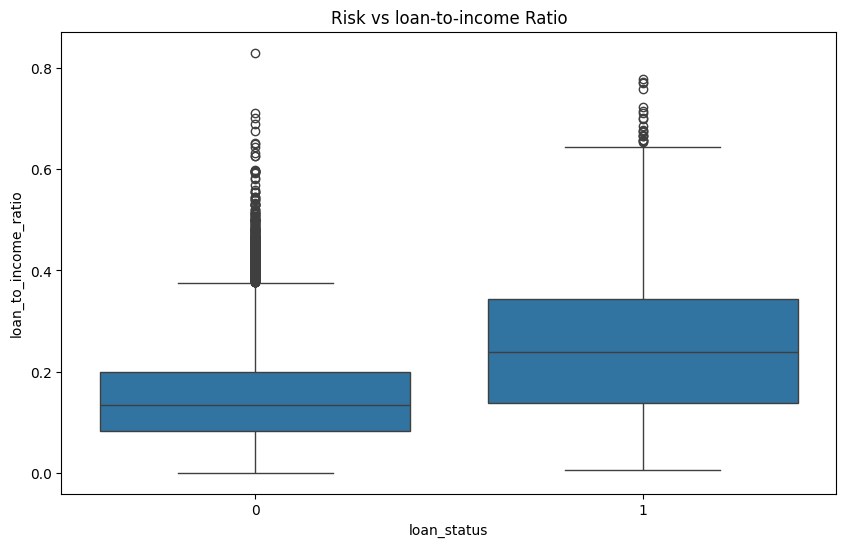

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt


# Create a boxplot to see how Loan-to-income Ratio affects Default
plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status',y='loan_to_income_ratio',data=df)
plt.title('Risk vs loan-to-income Ratio')
plt.show()

In [30]:
# let' see how many SAFE people have a ratio higher than the DEFAULT average (0.24)
high_ratio_safe = df[(df['loan_status']==0) & (df['loan_to_income_ratio']>0.24)].shape[0]
print(f"There are {high_ratio_safe} safe people who 'look' like risky borrowers" )

There are 3768 safe people who 'look' like risky borrowers


In [31]:
# Final Save
df.to_csv('credit_risk_cleaned_v2.csv')
print("Week1 Audit Complete. 3768 'Grey Area' cases identified for AI training") 

Week1 Audit Complete. 3768 'Grey Area' cases identified for AI training


In [33]:
# See the people who are extreme ouliers(Ratio> 0.5)
outliers = df[df['loan_to_income_ratio']>0.5]
print(f"There are {len(outliers)} extreme outliers in our data.")
print(outliers[['person_income','loan_amnt','loan_to_income_ratio','loan_status']].head())

There are 264 extreme outliers in our data.
    person_income  loan_amnt  loan_to_income_ratio  loan_status
2            9600       5500              0.572917            1
3           65500      35000              0.534351            1
4           54400      35000              0.643382            1
22          65000      34000              0.523077            1
36          48000      30000              0.625000            1
